In [16]:
# Read the SLMAG.XYZ file
# The file appears to be space-separated with column names in the first line
# There's a separator line after headers, but pandas can handle it
# Reading only the first 3 data rows for quick inspection
# Skip the separator line (line 1, 0-indexed)
import pandas as pd
df = pd.read_csv('data/SLMAG.XYZ', sep='\s+', header=0, skiprows=[1])

/var/folders/4m/sc07bkn154s8jfc7xp164by00000gq/T/ipykernel_58141/412927605.py:7: DtypeWarning: Columns (20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/SLMAG.XYZ', sep='\s+', header=0, skiprows=[1])


In [17]:
# Rename the column '/aircraft' to 'aircraft'
df = df.rename(columns={'/aircraft': 'aircraft'})

In [ ]:
df.head()

,aircraft,date,flight,line_number,line,line_part,fiducial,time_utc,gps_x_raw,gps_y_raw,...,grad_lev_lat,grad_raw_lon,grad_comp_lon,grad_lag_lon,grad_rot_lon,grad_lev_lon,pitch,roll,yaw,azimuth
0,JBG,2016/07/16,30,10,10,0,25.0,48313.0,345200.0,5517545.0,...,0.0030,-15.160,-0.208,-0.381,-0.0384,-0.0588,2.3,0.4,2.3,357.7
1,JBG,2016/07/16,30,10,10,0,25.1,48313.1,345200.0,5517552.6,...,-0.0006,-15.251,-0.264,-0.411,-0.0416,-0.0620,2.0,0.0,2.2,357.8
2,JBG,2016/07/16,30,10,10,0,25.2,48313.2,345200.0,5517560.2,...,-0.0035,-15.345,-0.317,-0.438,-0.0446,-0.0649,1.8,-0.3,2.1,357.9
3,JBG,2016/07/16,30,10,10,0,25.3,48313.3,345200.0,5517567.8,...,-0.0047,-15.439,-0.364,-0.473,-0.0481,-0.0685,1.5,-0.7,2.1,357.9
4,JBG,2016/07/16,30,10,10,0,25.4,48313.4,345200.0,5517575.4,...,-0.0038,-15.525,-0.398,-0.513,-0.0523,-0.0726,1.2,-1.1,2.0,358.0


In [12]:
print(df.columns.tolist())

['aircraft', 'date', 'flight', 'line_number', 'line', 'line_part', 'fiducial', 'time_utc', 'gps_x_raw', 'gps_y_raw', 'gps_z_raw', 'gps_x_final', 'gps_y_final', 'gps_z_final', 'x_nad83', 'y_nad83', 'lon_nad83', 'lat_nad83', 'radar1_raw', 'radar2_raw', 'radar_final', 'dem', 'mag_base1_raw', 'mag_base2_raw', 'mag_base1', 'mag_base2', 'fluxgate_x', 'fluxgate_y', 'fluxgate_z', 'mag_raw_left', 'mag_raw_right', 'mag_raw_tail', 'mag_comp_left', 'mag_comp_right', 'mag_comp_tail', 'mag_lag_left', 'mag_lag_right', 'mag_lag_tail', 'mag_diurn1_tail', 'mag_diurn2_tail', 'igrf', 'mag_miclev_tail', 'mag_lev_tail', 'mag_final_tail', 'mag_gsclev_tail', 'grad_raw_lat', 'grad_comp_lat', 'grad_lag_lat', 'grad_rot_lat', 'grad_lev_lat', 'grad_raw_lon', 'grad_comp_lon', 'grad_lag_lon', 'grad_rot_lon', 'grad_lev_lon', 'pitch', 'roll', 'yaw', 'azimuth']


In [21]:
# Read shapefile and filter data within boundary
import geopandas as gpd
from shapely.geometry import Point
import os

# Enable restoration of missing .shx index file
os.environ['SHAPE_RESTORE_SHX'] = 'YES'

# Load the shapefile
shapefile = gpd.read_file('data/ZL_boundary1.shp')
print(f"Shapefile loaded. CRS: {shapefile.crs}")

# Convert dataframe to GeoDataFrame using x_nad83, y_nad83 coordinates
# Use efficient method for large dataframes
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['x_nad83'], df['y_nad83']), crs='EPSG:26915')

# Spatial join to find points within the shapefile boundary
df_within_boundary = gpd.sjoin(gdf, shapefile, how='inner', predicate='within')

print(f"\nOriginal dataframe shape: {df.shape}")
print(f"Filtered dataframe (within boundary) shape: {df_within_boundary.shape}")
print(f"GeoDataFrame CRS: {gdf.crs}")

Shapefile loaded. CRS: None


/var/folders/4m/sc07bkn154s8jfc7xp164by00000gq/T/ipykernel_58141/3640079501.py:18: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:26915
Right CRS: None

  df_within_boundary = gpd.sjoin(gdf, shapefile, how='inner', predicate='within')



Original dataframe shape: (16023981, 59)
Filtered dataframe (within boundary) shape: (0, 61)
GeoDataFrame CRS: EPSG:26915


In [22]:
# Examine shapefile details and coordinate ranges
print("Shapefile info:")
print(shapefile.head())
print(f"\nShapefile bounds: {shapefile.total_bounds}")

print("\nGeoDataFrame (from SLMAG data):")
print(f"Bounds: {gdf.total_bounds}")
print(f"Sample coordinates (first 5 rows):\n{gdf[['x_nad83', 'y_nad83', 'geometry']].head()}")

# Check if the bounds overlap at all
print(f"\nDo bounds overlap? ")
print(f"X range in data: {gdf.geometry.x.min():.2f} to {gdf.geometry.x.max():.2f}")
print(f"Y range in data: {gdf.geometry.y.min():.2f} to {gdf.geometry.y.max():.2f}")

Shapefile info:
                                            geometry
0  POLYGON ((-94.74867 50.14212, -94.33117 50.142...

Shapefile bounds: [-94.74867444  49.86611215 -94.33117245  50.14212017]

GeoDataFrame (from SLMAG data):
Bounds: [ 345125.35 5515337.79  528849.9  5653795.12]
Sample coordinates (first 5 rows):
     x_nad83     y_nad83                      geometry
0  345200.16  5517546.03  POINT (345200.16 5517546.03)
1  345200.20  5517553.56   POINT (345200.2 5517553.56)
2  345200.24  5517561.09  POINT (345200.24 5517561.09)
3  345200.27  5517568.62  POINT (345200.27 5517568.62)
4  345200.31  5517576.15  POINT (345200.31 5517576.15)

Do bounds overlap? 
X range in data: 345125.35 to 528849.90
Y range in data: 5515337.79 to 5653795.12


In [30]:
# Set the CRS for shapefile (it's in lat/lon, so WGS84) and then reproject to UTM
# First, assign the CRS to the shapefile
shapefile = shapefile.set_crs('EPSG:4326')

# Now reproject to match the data CRS (UTM Zone 15N)
shapefile_reprojected = shapefile.to_crs('EPSG:26915')

print("Reprojected shapefile bounds:")
print(f"  {shapefile_reprojected.total_bounds}")

# Spatial join to find points within the original boundary (no buffer)
df_within_boundary = gpd.sjoin(gdf, shapefile_reprojected, how='inner', predicate='within')

print(f"\nOriginal dataframe rows: {df.shape[0]:,}")
print(f"Filtered dataframe (within boundary) rows: {df_within_boundary.shape[0]:,}")
print(f"Percentage of data within boundary: {(df_within_boundary.shape[0] / df.shape[0] * 100):.2f}%")

# Show some sample rows from the filtered data
print(f"\nSample rows from filtered data:")
print(df_within_boundary[['aircraft', 'x_nad83', 'y_nad83', 'lat_nad83', 'lon_nad83']].head())

Reprojected shapefile bounds:
  [ 374383.6264466  5524597.90482955  404881.81085284 5555896.35180345]

Original dataframe rows: 16,023,981
Filtered dataframe (within boundary) rows: 690,326
Percentage of data within boundary: 4.31%

Sample rows from filtered data:
        aircraft    x_nad83     y_nad83  lat_nad83  lon_nad83
2035094      LDX  374395.76  5525766.07  49.871116 -94.747985
2035095      LDX  374395.81  5525758.85  49.871051 -94.747981
2035096      LDX  374395.86  5525751.64  49.870986 -94.747978
2035097      LDX  374395.92  5525744.43  49.870921 -94.747975
2035098      LDX  374395.97  5525737.22  49.870856 -94.747972


# Reading SLMAG.XYZ File with Pandas

This notebook demonstrates how to read the SLMAG.XYZ file, which contains geophysical data from a magnetic survey, using pandas.

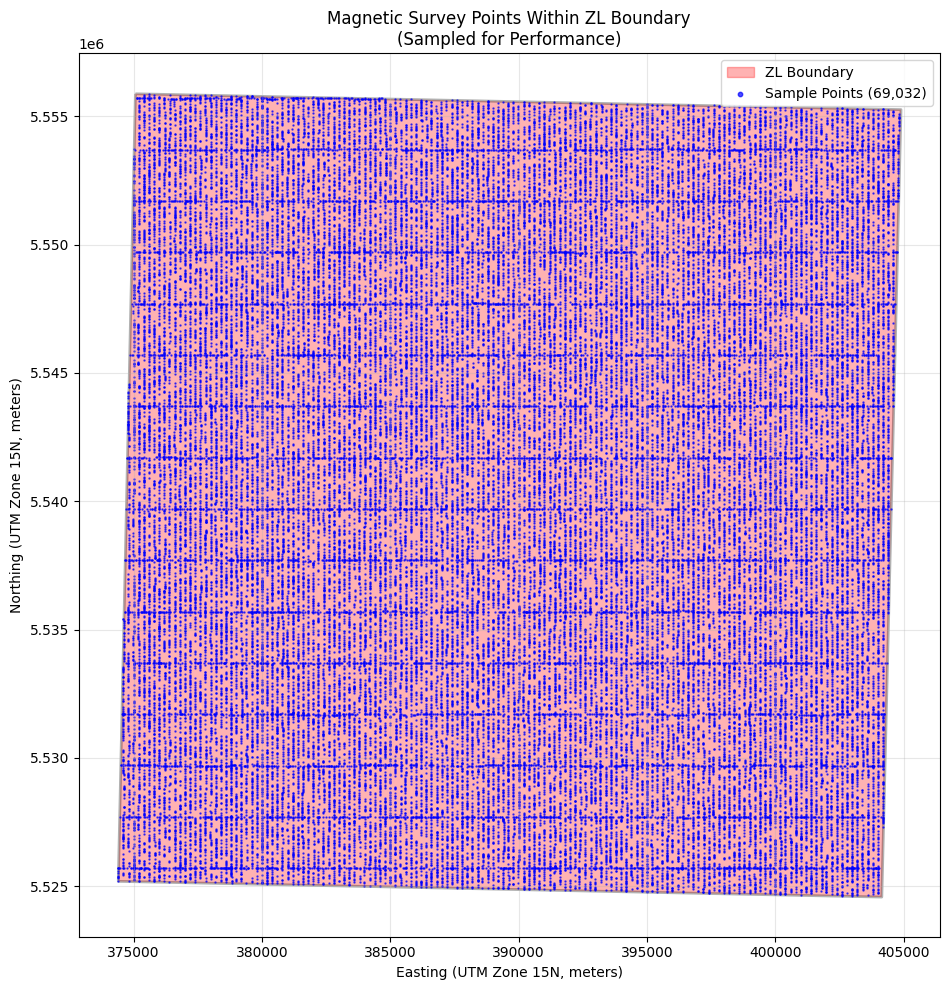

Total points within boundary: 690,326
Sampled for plotting: 69,032 points (10%)


In [32]:
# Plot the filtered points within the boundary
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the boundary (shapefile)
shapefile_reprojected.plot(ax=ax, facecolor='red', alpha=0.3, edgecolor='black', linewidth=2)

# Plot the points (sample for performance - plotting all 690k points would be slow)
# Sample 10% of the points for visualization
sample_size = int(len(df_within_boundary) * 0.1)
df_sample = df_within_boundary.sample(n=sample_size, random_state=42)

df_sample.plot(ax=ax, color='blue', markersize=0.5, alpha=0.7)

# Add labels and title
ax.set_xlabel('Easting (UTM Zone 15N, meters)')
ax.set_ylabel('Northing (UTM Zone 15N, meters)')
ax.set_title('Magnetic Survey Points Within ZL Boundary\n(Sampled for Performance)')

# Add custom legend
import matplotlib.patches as mpatches
boundary_patch = mpatches.Patch(color='red', alpha=0.3, label='ZL Boundary')
points_patch = plt.scatter([], [], color='blue', s=10, alpha=0.7, label=f'Sample Points ({sample_size:,})')
ax.legend(handles=[boundary_patch, points_patch])

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total points within boundary: {len(df_within_boundary):,}")
print(f"Sampled for plotting: {sample_size:,} points (10%)")

In [31]:
# Export the extracted data within the boundary to CSV
output_filename = 'data/SLMAG_ZL_boundary.csv'

# Export the dataframe (excluding the geometry column for cleaner CSV)
df_export = df_within_boundary.drop(columns=['geometry'])

df_export.to_csv(output_filename, index=False)

print(f"Exported {len(df_export):,} rows to {output_filename}")
print(f"File size estimate: {df_export.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
print(f"Columns exported: {list(df_export.columns)}")

Exported 690,326 rows to data/SLMAG_ZL_boundary.csv
File size estimate: 425.9 MB
Columns exported: ['aircraft', 'date', 'flight', 'line_number', 'line', 'line_part', 'fiducial', 'time_utc', 'gps_x_raw', 'gps_y_raw', 'gps_z_raw', 'gps_x_final', 'gps_y_final', 'gps_z_final', 'x_nad83', 'y_nad83', 'lon_nad83', 'lat_nad83', 'radar1_raw', 'radar2_raw', 'radar_final', 'dem', 'mag_base1_raw', 'mag_base2_raw', 'mag_base1', 'mag_base2', 'fluxgate_x', 'fluxgate_y', 'fluxgate_z', 'mag_raw_left', 'mag_raw_right', 'mag_raw_tail', 'mag_comp_left', 'mag_comp_right', 'mag_comp_tail', 'mag_lag_left', 'mag_lag_right', 'mag_lag_tail', 'mag_diurn1_tail', 'mag_diurn2_tail', 'igrf', 'mag_miclev_tail', 'mag_lev_tail', 'mag_final_tail', 'mag_gsclev_tail', 'grad_raw_lat', 'grad_comp_lat', 'grad_lag_lat', 'grad_rot_lat', 'grad_lev_lat', 'grad_raw_lon', 'grad_comp_lon', 'grad_lag_lon', 'grad_rot_lon', 'grad_lev_lon', 'pitch', 'roll', 'yaw', 'azimuth', 'index_right']
